## Part 2: Topic Modeling with BERTopic

**Project:** Management Accounting Research — Systematic Literature Review  
**Input:** `papers_preprocessed.csv` (produced by `01_Data.ipynb`)  

This notebook applies **BERTopic** to the preprocessed corpus of accounting journal articles. BERTopic combines sentence-transformer embeddings with UMAP dimensionality reduction and HDBSCAN clustering to produce coherent, human-interpretable topics. The pipeline is fully reproducible: embeddings are cached to disk and all model parameters are explicitly documented.

---

### Output files produced by this notebook

| File | Description |
|---|---|
| `embeddings.npy` | Cached sentence embeddings (skip recomputation on reruns) |
| `papers_with_topics.csv` | Full dataset with `topic_id` and `topic_probability` columns |
| `fig_topic_barchart.png/.html` | Top 20 topics by paper count |
| `fig_topic_keywords.png` | Per-topic c-TF-IDF keyword scores (top 10 topics) |
| `fig_topic_map.png/.html` | 2D UMAP document map coloured by topic |
| `fig_topics_over_time.png/.html` | Topic trajectories 2021–2026 |
| `topic_labeling_input.txt` | Structured input for LLM-assisted topic labeling |

---

### Install & Import Dependencies

The cell below installs all required packages silently. Re-running it is safe — pip skips packages that are already installed.

In [ ]:
import subprocess, sys

packages = [
    "bertopic",
    "sentence-transformers",
    "umap-learn",
    "hdbscan",
    "plotly",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "kaleido",   # required for plotly static PNG export
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

In [6]:
pip install bertopic

  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
Using cached bertopic-0.17.4-py3-none-any.whl (154 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
import re
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Imports successful.")

Imports successful.


---

## Step 10 — Load Data & Choose Corpus

Select the analysis corpus by setting `CORPUS_MODE` to one of four options:

| Mode | Source file | Description |
|---|---|---|
| `'full'` | `papers_preprocessed.csv` | All articles that passed document-type and abstract filters — baseline for field overview |
| `'MA_flag'` | `papers_preprocessed.csv` | Articles flagged as management-accounting-relevant via keyword screening (`is_management_accounting == True`) across **all journals** — **PRIMARY ANALYSIS CORPUS** |
| `'MA_journals'` | `papers_MA_journals.csv` | Articles from the three specialist MA journals only (MAR, JMAR, JOMAC) regardless of keyword flag |
| `'MA_strict'` | `papers_MA_strict.csv` | Articles that are **both** from the three MA journals **and** keyword-flagged — most focused corpus |

> **Primary analysis:** `MA_flag` is the recommended default. It captures management-accounting-relevant papers across the full journal set, giving broader coverage than `MA_journals` while still filtering for topical relevance.  
> Change `CORPUS_MODE` below to switch between corpora. The embeddings cache is automatically invalidated when the mode changes.

Documents shorter than 50 characters in `text_for_modeling` are dropped as they cannot produce meaningful embeddings.

In [ ]:
# ── Corpus mode — change this to switch analysis corpus ────────────────────────
CORPUS_MODE = 'MA_flag'   # ← PRIMARY ANALYSIS
#   Options:
#   'full'        → all articles from all journals  (papers_preprocessed.csv)
#   'MA_flag'     → MA-flagged articles across all journals (is_management_accounting == True)
#   'MA_journals' → only articles from MAR, JMAR, JOMAC   (papers_MA_journals.csv)
#   'MA_strict'   → MA-flagged AND from one of the 3 MA journals (papers_MA_strict.csv)

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
EMBEDDINGS_FILE = "embeddings.npy"
EMBEDDINGS_MODE_FILE = "embeddings_mode.txt"

# ── Select source file based on mode ──────────────────────────────────────────
_CORPUS_FILES = {
    "full":        "papers_preprocessed.csv",
    "MA_flag":     "papers_preprocessed.csv",
    "MA_journals": "papers_MA_journals.csv",
    "MA_strict":   "papers_MA_strict.csv",
}

if CORPUS_MODE not in _CORPUS_FILES:
    raise ValueError(f"Unknown CORPUS_MODE '{CORPUS_MODE}'. "
                     f"Choose from: {list(_CORPUS_FILES)}")

DATA_FILE = _CORPUS_FILES[CORPUS_MODE]

# ── Load ───────────────────────────────────────────────────────────────────────
df_all = pd.read_csv(DATA_FILE, dtype=str)
df_all["Year"] = pd.to_numeric(df_all["Year"], errors="coerce")
df_all["is_management_accounting"] = df_all["is_management_accounting"].map(
    {"True": True, "False": False, True: True, False: False}
)

print(f"Loaded {len(df_all):,} rows from {DATA_FILE}")

# ── Select corpus rows ─────────────────────────────────────────────────────────
if CORPUS_MODE == "MA_flag":
    df_model = df_all[df_all["is_management_accounting"] == True].copy()
else:
    # 'full', 'MA_journals', 'MA_strict' — file is already pre-filtered
    df_model = df_all.copy()

# Drop rows with missing or very short text_for_modeling
df_model["text_for_modeling"] = df_model["text_for_modeling"].fillna("").str.strip()
df_model = df_model[df_model["text_for_modeling"].str.len() >= 50].copy()
df_model.reset_index(drop=True, inplace=True)

docs = df_model["text_for_modeling"].tolist()

# ── Confirmation ───────────────────────────────────────────────────────────────
journals_present = sorted(df_model["Source title"].dropna().unique().tolist())
year_min = int(df_model["Year"].min()) if df_model["Year"].notna().any() else "N/A"
year_max = int(df_model["Year"].max()) if df_model["Year"].notna().any() else "N/A"

print(f"\nCorpus mode       : {CORPUS_MODE}")
print(f"Papers loaded     : {len(docs):,}")
print(f"Journals represented:")
for j in journals_present:
    print(f"  • {j}")
print(f"Year range        : {year_min} – {year_max}")

---

## Step 11 — Sentence Embeddings

We encode every document using **`all-MiniLM-L6-v2`**, a lightweight but high-quality sentence-transformer model that maps variable-length text to a 384-dimensional dense vector.

> **Why `text_for_modeling` and not `abstract_clean`?**  
> BERTopic relies on a transformer's contextual language understanding, not bag-of-words statistics. The model reads semantic meaning from complete, natural sentences — punctuation, articles, and word order all contribute to the embedding. Feeding it the stopword-stripped `abstract_clean` would degrade embedding quality. The cleaned text is reserved for TF-IDF-based keyword extraction (inside BERTopic's `CountVectorizer` component), where noise reduction is beneficial.

Embeddings are cached to `embeddings.npy`. On subsequent runs the file is loaded directly, saving several minutes of computation.

In [ ]:
# ── Check embeddings cache validity ───────────────────────────────────────────
# The cache is valid only when both the .npy file exists AND the mode recorded
# in embeddings_mode.txt matches the current CORPUS_MODE.
embeddings = None

if os.path.exists(EMBEDDINGS_FILE) and os.path.exists(EMBEDDINGS_MODE_FILE):
    with open(EMBEDDINGS_MODE_FILE, "r", encoding="utf-8") as _f:
        cached_mode = _f.read().strip()
    if cached_mode == CORPUS_MODE:
        embeddings = np.load(EMBEDDINGS_FILE)
        print(f"Loaded cached embeddings from '{EMBEDDINGS_FILE}'  [mode: {cached_mode}]")
        if embeddings.shape[0] != len(docs):
            print(
                f"  WARNING: cache has {embeddings.shape[0]} rows but corpus has {len(docs)} docs. "
                "Recomputing embeddings."
            )
            embeddings = None
    else:
        print(f"Corpus mode changed ({cached_mode!r} → {CORPUS_MODE!r}). Recomputing embeddings.")
else:
    print("No valid embeddings cache found. Computing from scratch.")

# ── Compute if needed ─────────────────────────────────────────────────────────
if embeddings is None:
    print(f"Computing embeddings with '{EMBEDDING_MODEL}' ...")
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)
    embeddings = sentence_model.encode(
        docs,
        show_progress_bar=True,
        batch_size=64
    )
    np.save(EMBEDDINGS_FILE, embeddings)
    with open(EMBEDDINGS_MODE_FILE, "w", encoding="utf-8") as _f:
        _f.write(CORPUS_MODE)
    print(f"Embeddings saved to '{EMBEDDINGS_FILE}'")
    print(f"Mode recorded in '{EMBEDDINGS_MODE_FILE}'  [mode: {CORPUS_MODE}]")

print(f"\nEmbedding shape : {embeddings.shape}  ({embeddings.shape[0]} docs × {embeddings.shape[1]} dims)")

---

## Step 12 — Configure and Run BERTopic

BERTopic is a modular pipeline; each component is configured explicitly:

| Component | Role | Key parameters |
|---|---|---|
| **UMAP** | Dimensionality reduction | `n_neighbors=15` balances local vs. global structure; `n_components=5` retains enough signal for HDBSCAN; `metric='cosine'` is appropriate for normalised text embeddings; `min_dist=0.0` produces tighter clusters |
| **HDBSCAN** | Density-based clustering | `min_cluster_size=15` sets the minimum papers per topic; `prediction_data=True` enables soft-cluster probabilities |
| **CountVectorizer** | c-TF-IDF keyword extraction | `ngram_range=(1,2)` captures important bigrams (e.g. *performance measurement*); `min_df=3` drops hapax legomena |
| **BERTopic** | Orchestration | `top_n_words=10` per topic; `verbose=True` for progress reporting |

The model is fit in one call; `topics` is a list of integer topic IDs (−1 = noise) and `probs` contains the soft-assignment probabilities.

In [10]:
# ── Sub-model configuration ────────────────────────────────────────────────────
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

# ── Fit ───────────────────────────────────────────────────────────────────────
topics, probs = topic_model.fit_transform(docs, embeddings)

# Flatten probs if HDBSCAN returns a matrix (soft-clustering)
if isinstance(probs, np.ndarray) and probs.ndim == 2:
    topic_probs = probs.max(axis=1)
else:
    topic_probs = np.array(probs) if not isinstance(probs, np.ndarray) else probs

# ── Summary ───────────────────────────────────────────────────────────────────
unique_topics   = sorted(set(topics))
n_topics        = len([t for t in unique_topics if t != -1])
n_noise         = sum(1 for t in topics if t == -1)

print(f"\nTopics found (excl. noise) : {n_topics}")
print(f"Noise papers (topic = -1)  : {n_noise:,} ({n_noise / len(topics) * 100:.1f}%)")

print("\nTop 5 largest topics:")
topic_info = topic_model.get_topic_info()
top5 = topic_info[topic_info["Topic"] != -1].head(5)
for _, row in top5.iterrows():
    kws = ", ".join([w for w, _ in topic_model.get_topic(row["Topic"])[:5]])
    print(f"  Topic {row['Topic']:>3d} | {row['Count']:>4} papers | {kws}")

2026-03-19 19:17:22,643 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 19:17:39,522 - BERTopic - Dimensionality - Completed ✓
2026-03-19 19:17:39,524 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 19:17:39,671 - BERTopic - Cluster - Completed ✓
2026-03-19 19:17:39,682 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 19:17:40,923 - BERTopic - Representation - Completed ✓



Topics found (excl. noise) : 23
Noise papers (topic = -1)  : 510 (22.1%)

Top 5 largest topics:
  Topic   0 |  538 papers | audit, auditors, accounting, quality, auditor
  Topic   1 |  176 papers | tax, avoidance, firms, taxes, corporate
  Topic   2 |  142 papers | employees, performance, control, employee, effort
  Topic   3 |  118 papers | compensation, ceo, performance, ceos, pay
  Topic   4 |  114 papers | analysts, forecasts, analyst, forecast, earnings


---

## Step 13 — Topic Overview Table

We build a human-readable topic summary table and merge topic assignments back into the main dataframe. The result is saved as `papers_with_topics.csv` for use in the analysis sections of the paper.

In [11]:
# ── Topic overview dataframe ───────────────────────────────────────────────────
topic_info = topic_model.get_topic_info().copy()

def get_top_keywords(topic_id, n=7):
    words = topic_model.get_topic(topic_id)
    if not words:
        return ""
    return ", ".join([w for w, _ in words[:n]])

topic_info["top_keywords"] = topic_info["Topic"].apply(
    lambda t: get_top_keywords(t) if t != -1 else "[noise]"
)

topic_overview = (
    topic_info[topic_info["Topic"] != -1]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
    [["Topic", "Count", "top_keywords"]]
)

print(f"Topic overview ({len(topic_overview)} topics):")
pd.set_option("display.max_colwidth", 120)
display(topic_overview)

# ── Merge back into df_model ───────────────────────────────────────────────────
df_model["topic_id"]          = topics
df_model["topic_probability"] = topic_probs

# Add keyword label for convenience
kw_map = {row["Topic"]: row["top_keywords"] for _, row in topic_info.iterrows()}
df_model["topic_keywords"] = df_model["topic_id"].map(kw_map).fillna("[noise]")

df_model.to_csv("papers_with_topics.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved papers_with_topics.csv  ({len(df_model):,} rows)")

Topic overview (23 topics):


,Topic,Count,top_keywords
0,0,538,"audit, auditors, accounting, quality, auditor, audit quality, clients"
1,1,176,"tax, avoidance, firms, taxes, corporate, corporate tax, planning"
2,2,142,"employees, performance, control, employee, effort, managers, experiment"
3,3,118,"compensation, ceo, performance, ceos, pay, incentives, executive"
4,4,114,"analysts, forecasts, analyst, forecast, earnings, information, research"
5,5,114,"fraud, sec, political, misconduct, firms, enforcement, financial"
6,6,67,"banks, bank, loan, loss, loan loss, loans, credit"
7,7,61,"loan, borrowers, lenders, debt, lending, information, covenants"
8,8,57,"disclosure, firms, private, information, public, disclosures, ipo"
9,9,52,"environmental, climate, disclosure, sustainability, firms, disclosures, climate change"



Saved papers_with_topics.csv  (2,311 rows)


---

## Step 14 — Visualizations

Four visualizations provide different perspectives on the topic structure:
- **14a** — volume ranking of topics
- **14b** — keyword weight profiles (what drives each topic)
- **14c** — spatial document map (semantic proximity)
- **14d** — temporal evolution of topics across 2021–2026

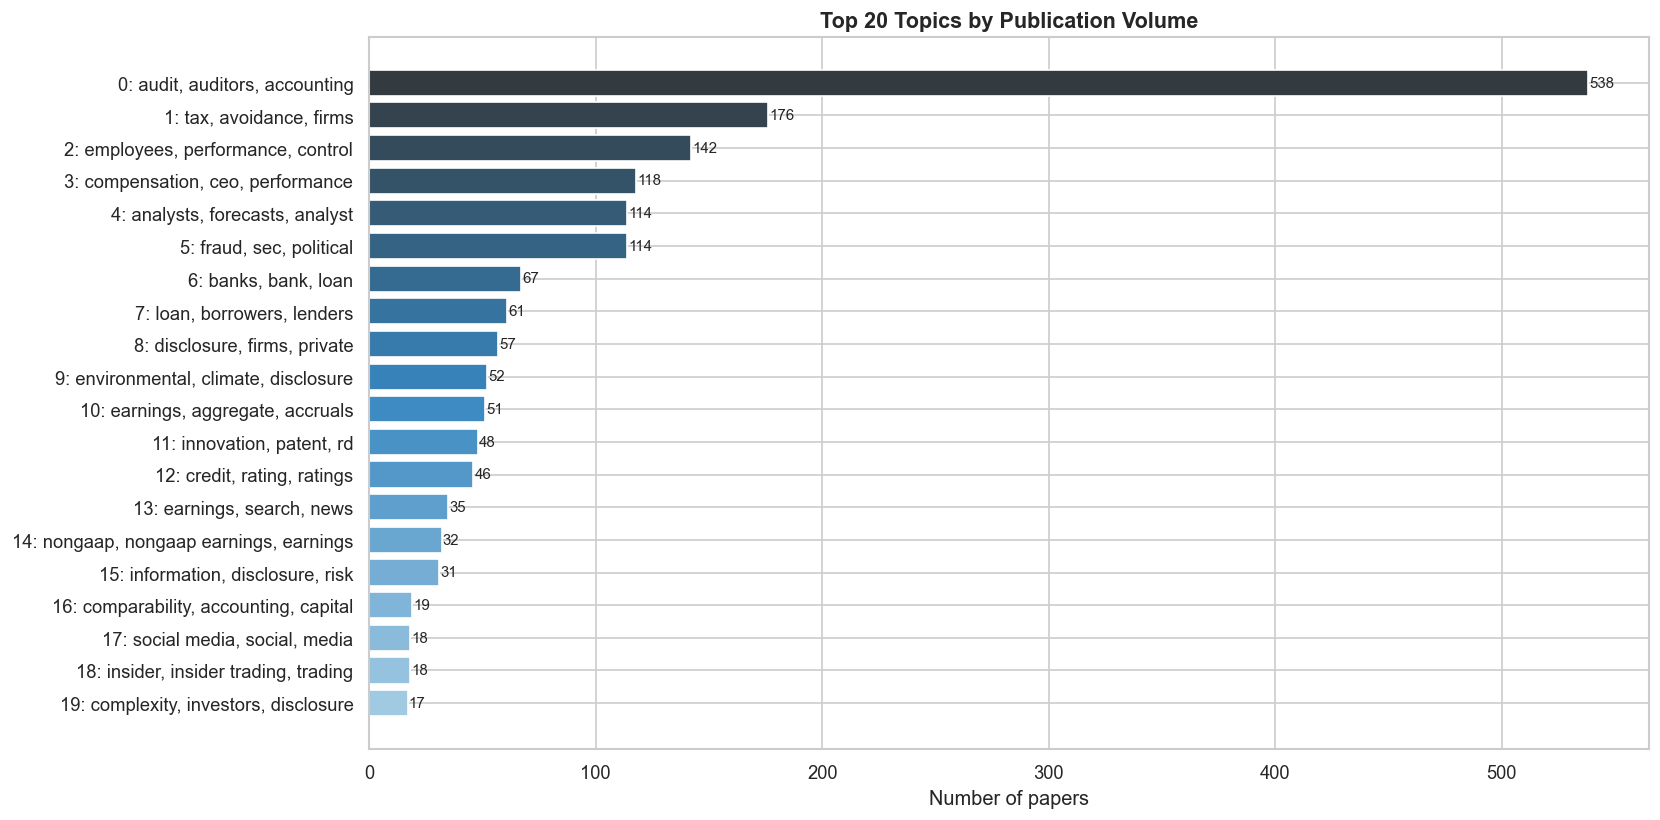

Saved fig_topic_barchart.png and .html


In [12]:
# ── 14a: Top 20 topics by paper count ─────────────────────────────────────────
top20 = topic_overview.head(20).copy()
top20["label"] = top20["Topic"].astype(str) + ": " + top20["top_keywords"].str.split(",").str[:3].str.join(",")

fig_bar, ax_bar = plt.subplots(figsize=(14, 7))
bars = ax_bar.barh(top20["label"][::-1], top20["Count"][::-1], color=sns.color_palette("Blues_d", len(top20)))
for bar in bars:
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width())}", va="center", fontsize=9)
ax_bar.set_title("Top 20 Topics by Publication Volume", fontsize=13, fontweight="bold")
ax_bar.set_xlabel("Number of papers")
ax_bar.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_topic_barchart.png", bbox_inches="tight")
plt.show()

# Interactive version
fig_bar_px = px.bar(
    top20,
    x="Count", y="label", orientation="h",
    title="Top 20 Topics by Publication Volume",
    labels={"Count": "Number of papers", "label": ""},
    color="Count", color_continuous_scale="Blues"
)
fig_bar_px.update_layout(yaxis={"categoryorder": "total ascending"})
fig_bar_px.write_html("fig_topic_barchart.html")
print("Saved fig_topic_barchart.png and .html")

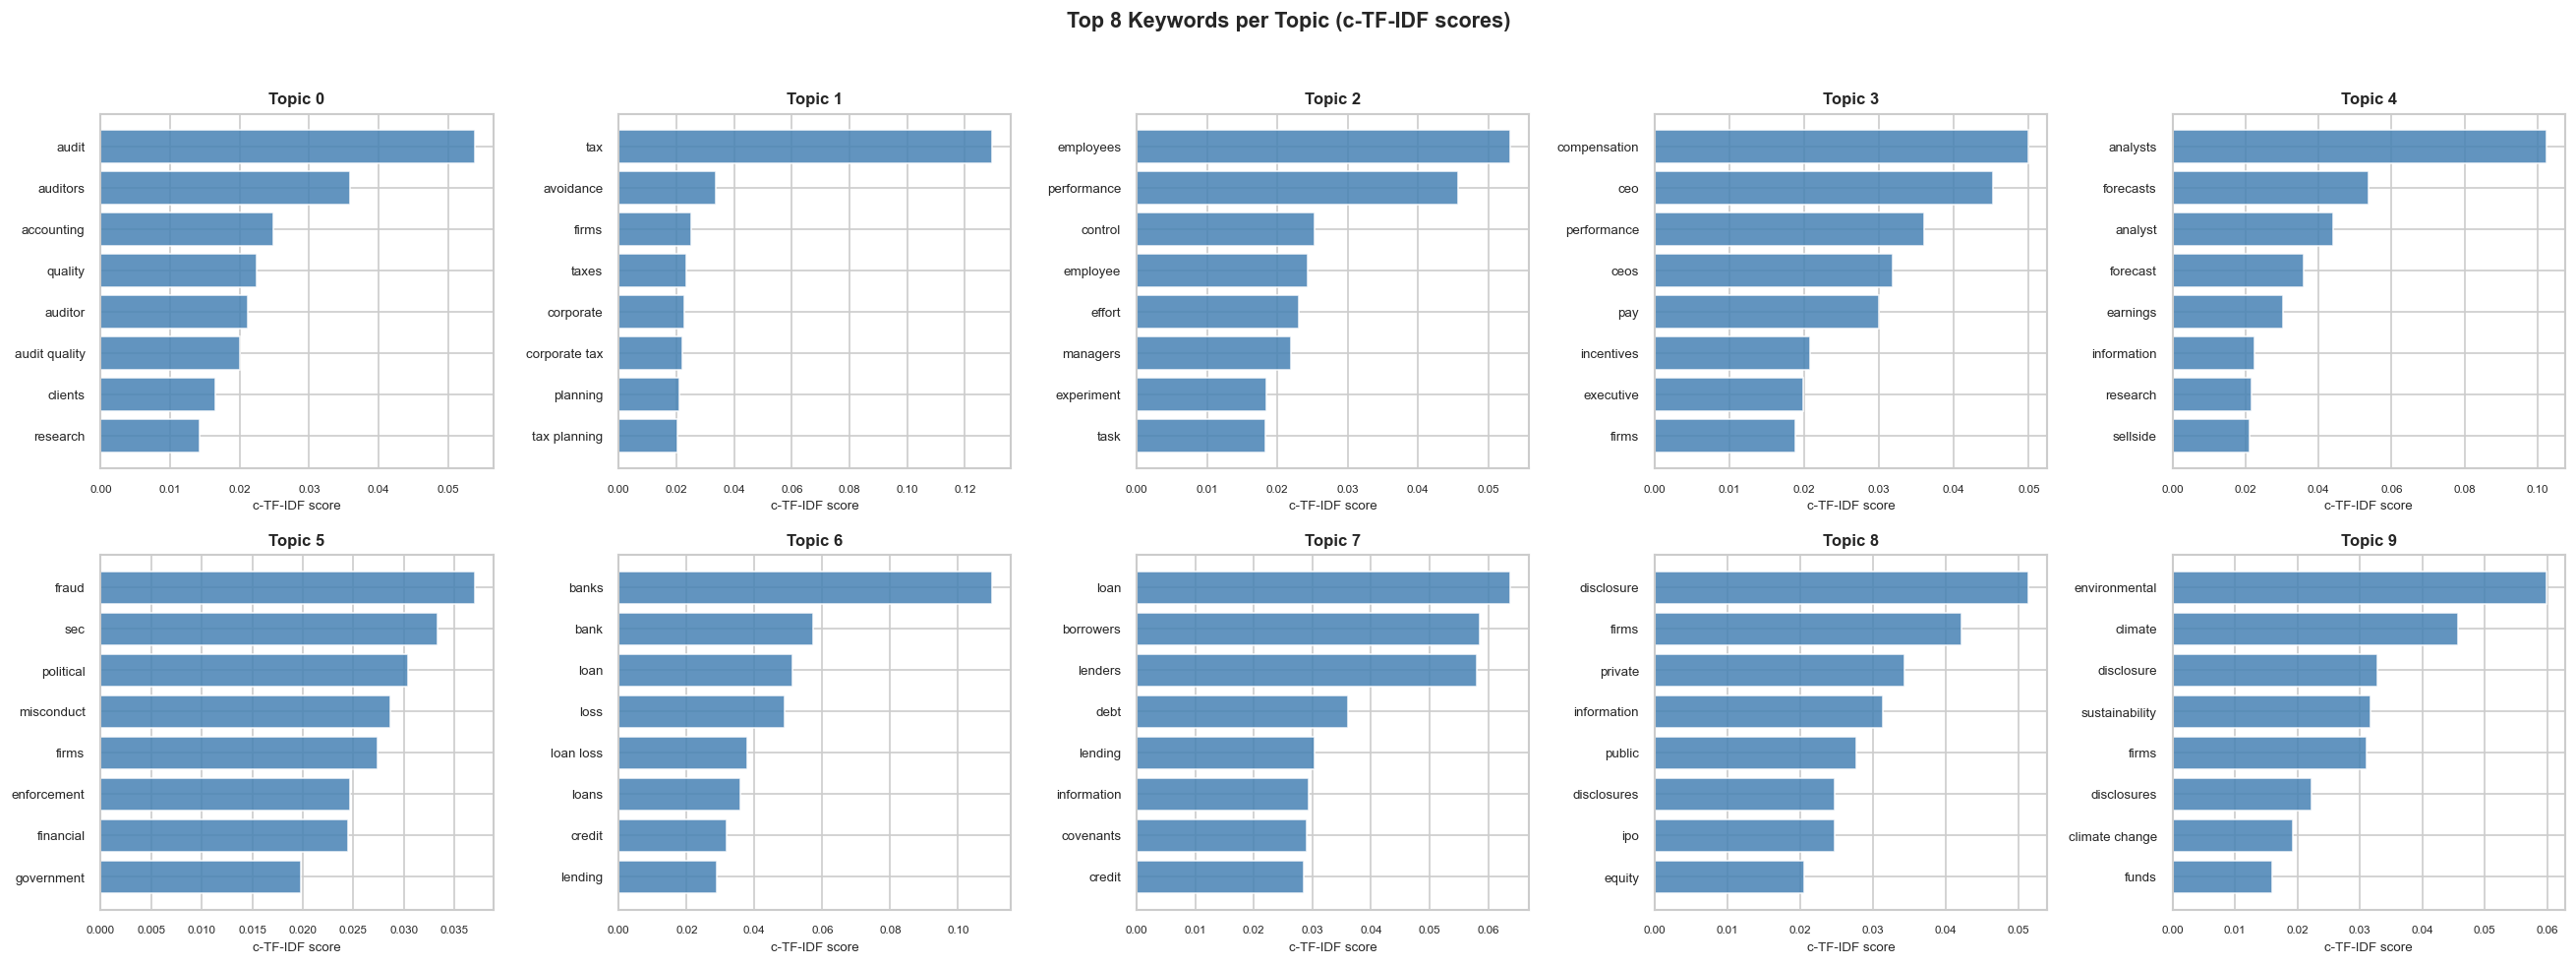

Saved fig_topic_keywords.png


In [13]:
# ── 14b: Keyword scores for top 10 topics (2×5 grid) ──────────────────────────
top10_ids = topic_overview.head(10)["Topic"].tolist()

fig_kw, axes_kw = plt.subplots(2, 5, figsize=(22, 8))
axes_kw = axes_kw.flatten()

for idx, topic_id in enumerate(top10_ids):
    words_scores = topic_model.get_topic(topic_id)[:8]
    if not words_scores:
        continue
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]
    ax = axes_kw[idx]
    bars_kw = ax.barh(words, scores, color="steelblue", alpha=0.85)
    ax.set_title(f"Topic {topic_id}", fontsize=10, fontweight="bold")
    ax.set_xlabel("c-TF-IDF score", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)

# Hide any unused subplots
for j in range(len(top10_ids), len(axes_kw)):
    axes_kw[j].set_visible(False)

fig_kw.suptitle("Top 8 Keywords per Topic (c-TF-IDF scores)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_topic_keywords.png", bbox_inches="tight")
plt.show()
print("Saved fig_topic_keywords.png")

Computing 2D UMAP for visualization ...


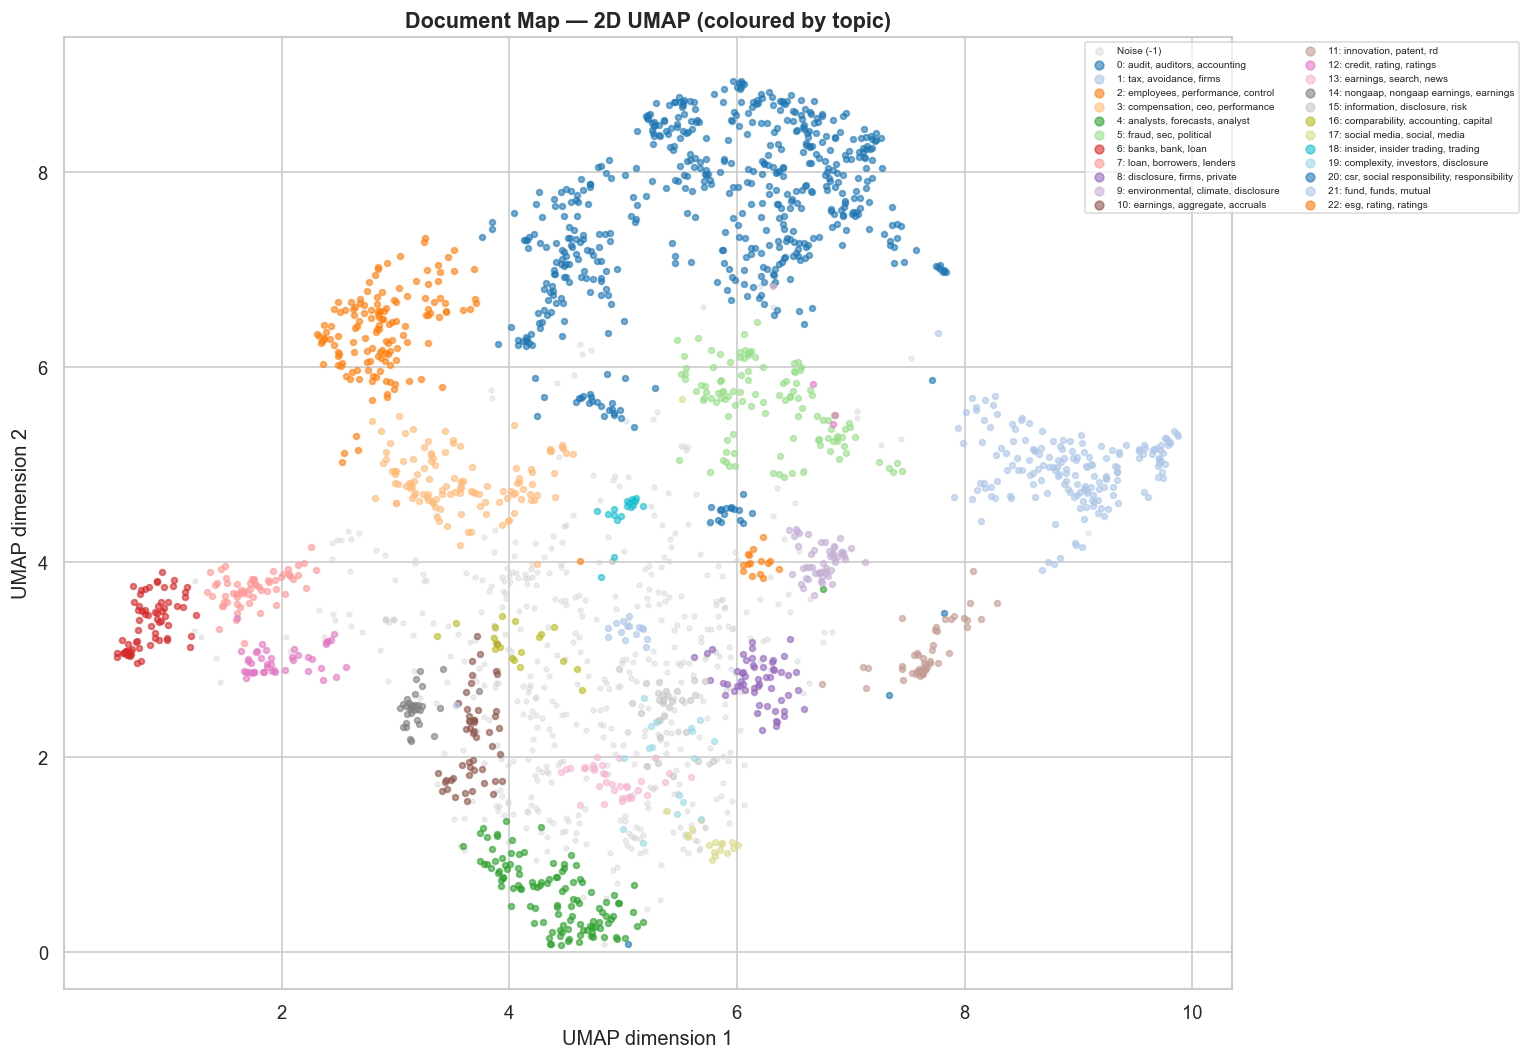

Saved fig_topic_map.png and .html


In [14]:
# ── 14c: 2D UMAP document map ──────────────────────────────────────────────────
# Run a separate 2-component UMAP purely for visualization (NOT used in modeling)
print("Computing 2D UMAP for visualization ...")
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.1,
               metric="cosine", random_state=42)
coords_2d = umap_2d.fit_transform(embeddings)

df_map = df_model[["Title", "Source title", "Year", "topic_id", "topic_keywords"]].copy()
df_map["umap_x"] = coords_2d[:, 0]
df_map["umap_y"] = coords_2d[:, 1]
df_map["topic_label"] = df_map["topic_id"].astype(str) + ": " + \
    df_map["topic_keywords"].str.split(",").str[:3].str.join(",")

# Static version
non_noise = df_map[df_map["topic_id"] != -1]
noise_pts = df_map[df_map["topic_id"] == -1]

fig_map, ax_map = plt.subplots(figsize=(13, 9))
palette = sns.color_palette("tab20", n_colors=min(20, df_map["topic_id"].nunique()))

ax_map.scatter(noise_pts["umap_x"], noise_pts["umap_y"],
               c="lightgrey", s=8, alpha=0.4, label="Noise (-1)", zorder=1)

for i, tid in enumerate(sorted(non_noise["topic_id"].unique())):
    subset = non_noise[non_noise["topic_id"] == tid]
    kws = ", ".join(get_top_keywords(tid, n=3).split(", "))
    ax_map.scatter(subset["umap_x"], subset["umap_y"],
                   s=12, alpha=0.6, label=f"{tid}: {kws}",
                   color=palette[i % 20], zorder=2)

ax_map.set_title("Document Map — 2D UMAP (coloured by topic)", fontsize=13, fontweight="bold")
ax_map.set_xlabel("UMAP dimension 1")
ax_map.set_ylabel("UMAP dimension 2")
ax_map.legend(fontsize=6, loc="upper right", ncol=2,
              framealpha=0.7, markerscale=1.5,
              bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.savefig("fig_topic_map.png", bbox_inches="tight")
plt.show()

# Interactive plotly version (hover shows title)
df_map_plot = df_map.copy()
df_map_plot["topic_str"] = df_map_plot["topic_id"].astype(str)

fig_map_px = px.scatter(
    df_map_plot,
    x="umap_x", y="umap_y",
    color="topic_str",
    hover_data={"Title": True, "Source title": True, "Year": True,
                "topic_keywords": True, "umap_x": False, "umap_y": False},
    title="Document Map — 2D UMAP (interactive)",
    labels={"umap_x": "UMAP 1", "umap_y": "UMAP 2", "topic_str": "Topic"},
    opacity=0.6,
    width=1100, height=750
)
fig_map_px.update_traces(marker_size=4)
fig_map_px.write_html("fig_topic_map.html")
print("Saved fig_topic_map.png and .html")

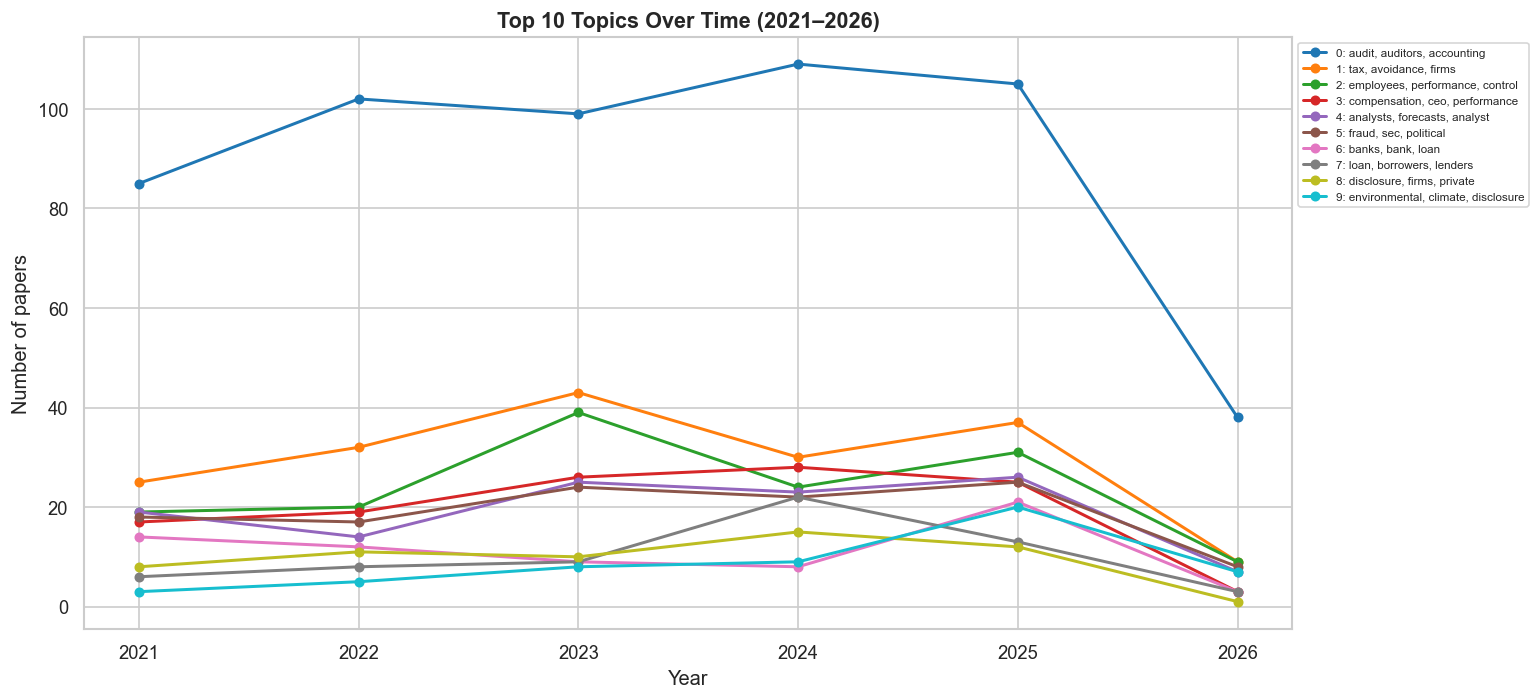

Saved fig_topics_over_time.png and .html


In [15]:
# ── 14d: Topics over time ──────────────────────────────────────────────────────
top10_topic_ids = topic_overview.head(10)["Topic"].tolist()

if "Year" in df_model.columns and df_model["Year"].notna().any():
    # Manual groupby (more reliable than BERTopic's built-in for publication years)
    tot = (
        df_model[df_model["topic_id"].isin(top10_topic_ids)]
        .groupby(["Year", "topic_id"])
        .size()
        .reset_index(name="count")
    )
    tot["Year"] = tot["Year"].astype(int)
    tot["topic_label"] = tot["topic_id"].apply(
        lambda t: f"{t}: {get_top_keywords(t, n=3)}"
    )

    # Static version
    fig_tot, ax_tot = plt.subplots(figsize=(13, 6))
    palette_tot = sns.color_palette("tab10", n_colors=len(top10_topic_ids))
    for i, tid in enumerate(top10_topic_ids):
        subset = tot[tot["topic_id"] == tid].sort_values("Year")
        lbl = f"{tid}: {get_top_keywords(tid, n=3)}"
        ax_tot.plot(subset["Year"], subset["count"],
                    marker="o", linewidth=1.8, markersize=5,
                    label=lbl, color=palette_tot[i])
    ax_tot.set_title("Top 10 Topics Over Time (2021–2026)", fontsize=13, fontweight="bold")
    ax_tot.set_xlabel("Year")
    ax_tot.set_ylabel("Number of papers")
    ax_tot.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax_tot.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig("fig_topics_over_time.png", bbox_inches="tight")
    plt.show()

    # Interactive version
    fig_tot_px = px.line(
        tot.sort_values(["topic_label", "Year"]),
        x="Year", y="count", color="topic_label",
        markers=True,
        title="Top 10 Topics Over Time (2021–2026)",
        labels={"count": "Papers", "topic_label": "Topic"},
        width=1100, height=600
    )
    fig_tot_px.write_html("fig_topics_over_time.html")
    print("Saved fig_topics_over_time.png and .html")
else:
    print("'Year' column not available — skipping topics-over-time chart.")

---

## Step 15 — Noise Inspection

Papers assigned to **topic −1** were not clustered by HDBSCAN because they did not lie in a sufficiently dense region of the embedding space. This is expected behaviour.

> **Why noise is methodologically preferable to forced assignment (LDA-style):**  
> Latent Dirichlet Allocation assigns every document to at least one topic regardless of whether a natural cluster exists. HDBSCAN with a noise label is more honest: papers that genuinely span multiple topics or represent niche, low-frequency themes are flagged rather than distorted. This produces cleaner, more interpretable topics at the cost of some coverage, which is an acceptable trade-off in corpus analytics.

In [16]:
df_noise = df_model[df_model["topic_id"] == -1][["Title", "Source title", "Year"]]

print(f"Total noise papers: {len(df_noise):,}  ({len(df_noise) / len(df_model) * 100:.1f}% of corpus)\n")

sample_size = min(10, len(df_noise))
print(f"Random sample of {sample_size} noise papers:")
display(
    df_noise.sample(sample_size, random_state=42).reset_index(drop=True)
)

Total noise papers: 510  (22.1% of corpus)

Random sample of 10 noise papers:


,Title,Source title,Year
0,Is hiring fast a good sign? The informativeness of job vacancy duration for future firm profitability,Review of Accounting Studies,2023
1,The disclosure quality consequences of copying standard-setter guidance,Review of Accounting Studies,2024
2,Earnings prediction with DuPont components and calibration by life cycle,Review of Accounting Studies,2024
3,Walk the talk: ESG mutual fund voting on shareholder proposals,Review of Accounting Studies,2022
4,Appraisal rights and corporate disclosure during mergers and acquisitions,Journal of Accounting and Economics,2023
5,"EDGAR Implementation, Unionization, and Strategic Disclosure",Accounting Review,2025
6,"Intangible Investments, Scaling, and the Trend in the Accrual–Cash Flow Association",Journal of Accounting Research,2022
7,"Management Going Concern Disclosure, Mitigation Plan, and Failure Prediction—Implications from ASU 2014-15",Accounting Review,2022
8,Are U.S. GAAP-based and IFRS-based accounting amounts more comparable after the revised lease standards? Evidence fr...,Review of Accounting Studies,2025
9,The Real Effects of Supply Chain Transparency Regulation: Evidence from Section 1502 of the Dodd–Frank Act,Journal of Accounting Research,2024


---

## Step 16 — Sensitivity Check

We re-run the model with a stricter `min_cluster_size=25` to assess how sensitive the topic structure is to this hyperparameter. Both configurations are compared on topic count and noise rate. This robustness check is reported in the methodology section of the paper.

In [ ]:
# ── Run 1: Stricter clustering on current corpus (min_cluster_size=25) ────────
print("Running sensitivity check 1/2: min_cluster_size=25 on current corpus ...")

hdbscan_strict = HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model_strict = BERTopic(
    umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                    metric="cosine", random_state=42),
    hdbscan_model=hdbscan_strict,
    vectorizer_model=CountVectorizer(ngram_range=(1, 2), stop_words="english", min_df=3),
    top_n_words=10,
    verbose=False
)
topics_strict, _ = topic_model_strict.fit_transform(docs, embeddings)

n_topics_main   = len([t for t in set(topics) if t != -1])
n_noise_main    = sum(1 for t in topics if t == -1)
pct_noise_main  = n_noise_main / len(topics) * 100

n_topics_strict  = len([t for t in set(topics_strict) if t != -1])
n_noise_strict   = sum(1 for t in topics_strict if t == -1)
pct_noise_strict = n_noise_strict / len(topics_strict) * 100

# ── Run 2: MA_journals corpus with min_cluster_size=15 ────────────────────────
print("Running sensitivity check 2/2: MA_journals corpus (min_cluster_size=15) ...")

_mj_file = "papers_MA_journals.csv"
if os.path.exists(_mj_file):
    _df_mj = pd.read_csv(_mj_file, dtype=str)
    _df_mj["text_for_modeling"] = _df_mj["text_for_modeling"].fillna("").str.strip()
    _df_mj = _df_mj[_df_mj["text_for_modeling"].str.len() >= 50].copy()
    _docs_mj = _df_mj["text_for_modeling"].tolist()

    if len(_docs_mj) >= 15:
        _sentence_model = SentenceTransformer(EMBEDDING_MODEL)
        _emb_mj = _sentence_model.encode(_docs_mj, show_progress_bar=False, batch_size=64)

        _tm_mj = BERTopic(
            umap_model=UMAP(n_neighbors=min(15, len(_docs_mj) - 1), n_components=5,
                            min_dist=0.0, metric="cosine", random_state=42),
            hdbscan_model=HDBSCAN(min_cluster_size=15, min_samples=5, metric="euclidean",
                                   cluster_selection_method="eom", prediction_data=True),
            vectorizer_model=CountVectorizer(ngram_range=(1, 2), stop_words="english", min_df=2),
            top_n_words=10,
            verbose=False
        )
        _topics_mj, _ = _tm_mj.fit_transform(_docs_mj, _emb_mj)
        n_topics_mj   = len([t for t in set(_topics_mj) if t != -1])
        n_noise_mj    = sum(1 for t in _topics_mj if t == -1)
        pct_noise_mj  = n_noise_mj / len(_topics_mj) * 100
        n_papers_mj   = len(_docs_mj)
    else:
        n_topics_mj  = "N/A (corpus too small)"
        n_noise_mj   = "—"
        pct_noise_mj = float("nan")
        n_papers_mj  = len(_docs_mj)
else:
    n_topics_mj  = "N/A (file not found)"
    n_noise_mj   = "—"
    pct_noise_mj = float("nan")
    n_papers_mj  = 0

# ── Comparison table ───────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Run": [
        f"Primary ({CORPUS_MODE})",
        f"Stricter clustering ({CORPUS_MODE})",
        "MA journals only",
    ],
    "Corpus": [CORPUS_MODE, CORPUS_MODE, "MA_journals"],
    "N Papers": [len(docs), len(docs), n_papers_mj],
    "min_cluster_size": [15, 25, 15],
    "Topics found": [n_topics_main, n_topics_strict, n_topics_mj],
    "Noise papers": [n_noise_main, n_noise_strict, n_noise_mj],
    "Noise %": [
        f"{pct_noise_main:.1f}%",
        f"{pct_noise_strict:.1f}%",
        f"{pct_noise_mj:.1f}%" if not (isinstance(pct_noise_mj, float) and
                                        pct_noise_mj != pct_noise_mj) else "—",
    ],
})

print("\nSensitivity comparison:")
display(comparison)

comparison.to_csv("sensitivity_check.csv", index=False, encoding="utf-8-sig")
print("\nSaved sensitivity_check.csv")
print(f"\nPrimary result (min_cluster_size=15, {CORPUS_MODE}) retained as main model.")

---

## Step 17 — AI Labeling Preparation

Automatically identified topics carry numeric IDs and keyword lists, but human-readable labels are required for the paper. We prepare a structured text file (`topic_labeling_input.txt`) that can be pasted directly into an LLM for expert labeling.

For each topic we include:
- The top 10 c-TF-IDF keywords
- The three highest-probability papers (title + first 300 characters of abstract)

---

### Prompt to use when pasting into Claude

```
You are an expert in management accounting and accounting research.
Below are topic clusters identified by a BERTopic model applied to
abstracts from leading accounting journals (2021–2026).

For each topic, provide:
1. A concise topic label (3–6 words, use accounting terminology)
2. Sub-field classification: Financial Accounting | Management Accounting |
   Auditing | Cross-cutting
3. One sentence explaining your classification

Be specific. Avoid generic labels like 'accounting research' or
'financial reporting'. Prefer labels like 'Real Earnings Management
and Accruals' or 'Sustainability Reporting and ESG Disclosure'.

[PASTE TOPIC BLOCKS HERE]
```

In [18]:
def build_topic_block(topic_id: int, df_papers: pd.DataFrame, n_reps: int = 3) -> str:
    """Build a structured text block for a single topic."""
    keywords = get_top_keywords(topic_id, n=10)

    # Select representative papers: highest topic_probability within this topic
    subset = (
        df_papers[df_papers["topic_id"] == topic_id]
        .sort_values("topic_probability", ascending=False)
        .head(n_reps)
        .reset_index(drop=True)
    )

    lines = [
        f"=== TOPIC {topic_id} ===",
        f"Top keywords: {keywords}",
        "",
    ]
    for i, row in subset.iterrows():
        title    = str(row.get("Title", "")).strip()
        abstract = str(row.get("Abstract", "")).strip()[:300]
        lines += [
            f"Representative Abstract {i + 1} (probability: {row['topic_probability']:.3f}):",
            f"Title: {title}",
            f"Abstract: {abstract}...",
            "",
        ]
    return "\n".join(lines)


# ── Build full output ──────────────────────────────────────────────────────────
all_topic_ids = topic_overview["Topic"].tolist()  # already sorted by Count desc, excl. -1

output_blocks = []
for tid in all_topic_ids:
    block = build_topic_block(tid, df_model)
    output_blocks.append(block)

full_output = "\n\n".join(output_blocks)

with open("topic_labeling_input.txt", "w", encoding="utf-8") as f:
    f.write(full_output)

print(f"Saved topic_labeling_input.txt  ({len(all_topic_ids)} topic blocks)")
print("\n" + "=" * 60)
print("PREVIEW — first 3 topic blocks:")
print("=" * 60)
preview = "\n\n".join(output_blocks[:3])
print(preview)

Saved topic_labeling_input.txt  (23 topic blocks)

PREVIEW — first 3 topic blocks:
=== TOPIC 0 ===
Top keywords: audit, auditors, accounting, quality, auditor, audit quality, clients, research, partners, study

Representative Abstract 1 (probability: 1.000):
Title: Decentralized Finance (DeFi) assurance: early evidence
Abstract: Decentralized finance (DeFi) has emerged to offer traditional financial services such as lending, borrowing, and trading without intermediaries (e.g., banks). DeFi transactions are typically executed using a special digital class of contracts called smart contracts. These contracts are self-executin...

Representative Abstract 2 (probability: 1.000):
Title: Do Shared Auditors Improve Audit Quality? Evidence from Banking Relationships
Abstract: Auditor knowledge is a key element in explaining the supply of audit quality, yet understanding of the drivers of this knowledge in the archival literature is limited. This study uses an archival approach to examine wheth

---

## Step 18 — Final Summary

Complete accounting of all modeling decisions and outputs produced in this notebook.

In [ ]:
# ── Retrieve largest topic info ────────────────────────────────────────────────
largest = topic_overview.iloc[0]
largest_label = f"Topic {largest['Topic']}: {largest['top_keywords']}"
largest_count = int(largest["Count"])

n_noise_final  = int((df_model["topic_id"] == -1).sum())
pct_noise_final = n_noise_final / len(df_model) * 100

saved_files = [
    "embeddings.npy",
    "papers_with_topics.csv",
    "fig_topic_barchart.png",
    "fig_topic_barchart.html",
    "fig_topic_keywords.png",
    "fig_topic_map.png",
    "fig_topic_map.html",
    "fig_topics_over_time.png",
    "fig_topics_over_time.html",
    "topic_labeling_input.txt",
]

summary_rows = [
    ("Corpus mode",           CORPUS_MODE),
    ("Total papers modeled",  f"{len(df_model):,}"),
    ("Embedding model",       EMBEDDING_MODEL),
    ("Topics found",          str(n_topics)),
    ("Noise cluster size",    f"{n_noise_final:,} ({pct_noise_final:.1f}%)"),
    ("Largest topic",         f"{largest_label}  [{largest_count} papers]"),
]

print("=" * 65)
print("  TOPIC MODELING — FINAL SUMMARY")
print("=" * 65)
for label, value in summary_rows:
    print(f"  {label:<30} {value}")
print()
print("  Files saved:")
for f in saved_files:
    exists = "✓" if os.path.exists(f) else "·"
    print(f"  [{exists}] {f}")
print("=" * 65)

---

## Part 3: Corpus Comparison

The table below compares all four corpus variants along key dimensions without re-running BERTopic. This provides the numbers needed for the methodology section robustness discussion.

> **Methodology note (copy into paper):**  
> *"The primary analysis was conducted on the MA_flag corpus (N = [X]), comprising management-accounting-relevant papers identified across all [N] journals via keyword screening. As a robustness check, the model was rerun on the MA_journals corpus (N = [Y]), restricted to the three specialist management accounting journals (MAR, JMAR, JOMAC). Results of both runs are reported in Appendix [X]."*

In [ ]:
# ── Load all four corpus CSVs ──────────────────────────────────────────────────
_MA_JOURNAL_PATTERNS = [
    "management accounting research",
    "journal of management accounting research",
    "journal of management control",
]

def _is_ma_journal(source_title: str) -> bool:
    st_lower = str(source_title).lower()
    return any(pat in st_lower for pat in _MA_JOURNAL_PATTERNS)

def _load_corpus(path: str, mode: str) -> pd.DataFrame:
    """Load a corpus CSV and apply in-memory filtering where needed."""
    if not os.path.exists(path):
        return pd.DataFrame()
    df_ = pd.read_csv(path, dtype=str)
    df_["is_management_accounting"] = df_["is_management_accounting"].map(
        {"True": True, "False": False, True: True, False: False}
    )
    df_["Year"] = pd.to_numeric(df_["Year"], errors="coerce")
    df_["text_for_modeling"] = df_["text_for_modeling"].fillna("").str.strip()
    df_ = df_[df_["text_for_modeling"].str.len() >= 50].copy()
    if mode == "MA_flag":
        df_ = df_[df_["is_management_accounting"] == True]
    return df_

_df_full        = _load_corpus("papers_preprocessed.csv", "full")
_df_ma_flag     = _load_corpus("papers_preprocessed.csv", "MA_flag")
_df_ma_journals = _load_corpus("papers_MA_journals.csv",  "MA_journals")
_df_ma_strict   = _load_corpus("papers_MA_strict.csv",    "MA_strict")

_n_full = len(_df_full)

def _fmt_row(label, df_, note):
    n        = len(df_)
    n_j      = df_["Source title"].nunique() if n > 0 else 0
    pct      = f"{n / _n_full * 100:.1f}%" if _n_full > 0 else "—"
    return {"Corpus Mode": label, "N Papers": n, "N Journals": n_j,
            "% of Full Corpus": pct, "Notes": note}

comparison_rows = [
    _fmt_row("full",        _df_full,        "Baseline"),
    _fmt_row("MA_flag",     _df_ma_flag,     "Primary result"),
    _fmt_row("MA_journals", _df_ma_journals, "MA specialist"),
    _fmt_row("MA_strict",   _df_ma_strict,   "Most focused"),
]

df_comparison = pd.DataFrame(comparison_rows)
print("Corpus comparison:")
display(df_comparison)

df_comparison.to_csv("corpus_comparison.csv", index=False, encoding="utf-8-sig")
print("\nSaved corpus_comparison.csv")

# ── Print methodology text with filled-in numbers ─────────────────────────────
_n_maf  = len(_df_ma_flag)
_n_mj   = len(_df_ma_journals)
_n_j_all = _df_ma_flag["Source title"].nunique() if _n_maf > 0 else "?"

print("\n── Methodology text (copy-paste into paper) ──────────────────────────────")
print(
    f'  "The primary analysis was conducted on the MA_flag corpus (N = {_n_maf:,}), '
    f'comprising management-accounting-relevant papers identified across all '
    f'{_n_j_all} journals via keyword screening. As a robustness check, the model '
    f'was rerun on the MA_journals corpus (N = {_n_mj:,}), restricted to the three '
    f'specialist management accounting journals (MAR, JMAR, JOMAC). '
    f'Results of both runs are reported in Appendix [X]."'
)